# CNG 7880 - Trustworthy and Explainable AI
## Term Project

**Author:** Mahrad Hosseini  
**Date:** May 2026

---

In this notebook I will implement 3 explainability methods namely Grad-CAM, LIME, and SHAP on 2 different models ResNet-18 and DeiT-T, both trained on FloodNet.
For the methods I will use pytorch_grad_cam, lime, and shap libraries respectively.

In [1]:
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as T
import timm
import shap

from PIL import Image
from tqdm.auto import tqdm
from torch.utils.data import Dataset
from torchvision.models import resnet18
from lime import lime_image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from skimage.segmentation import mark_boundaries, quickshift, slic

/home/mahrad/miniconda3/envs/arcis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Here I define the constants. My dataset is a multi-label dataset with 9 labels in total, we will examine 2 of them, "buildingFlooded" and "roadFlooded", which are among the most important ones for us.  
"MEAN" and "STD" come from ImageNet's mean and standard deviation since my models were pre-trained on ImageNet.

In [2]:
# Confings
DATA_DIR = Path("Data")
MODELS_DIR = Path("Models")
RESULTS_DIR = Path("Results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_NAMES = ["ResNet-18", "DeiT-T"]
MULTILABEL_NAMES = [
    "buildingAny",
    "buildingFlooded",
    "roadAny",
    "roadFlooded",
    "water",
    "tree",
    "vehicle",
    "pool",
    "grass"
]
NUM_LABELS = len(MULTILABEL_NAMES)
LABELS_UNDER_TEST = ["buildingFlooded", "roadFlooded"]
NTH_SAMPLE = 7

PRECOMP_WORKERS = 32
THRESHOLD = 0.5

SEED = 888
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MEAN = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)
print(f"Device: {DEVICE}")
print(f"Num Labels: {NUM_LABELS}")

Device: cuda
Num Labels: 9


This cell loads the data from 'Data' directory, then labels it. The original FloodNet dataset is a segmentation dataset, I turn it into an image-level classification dataset by saying: if any pixel in the segmentation mask has value c, then label c is present in that image.  

Also, because the whole dataset is around 13GB, and I wanted this repo to be self-contained, I only included the test split, and resized it to 224x224 which is the same input size as the model expects.  

And yes, we only need few images from the dataset, but I load the whole split so that we can play around with different images.

In [3]:
# Let's load the dataset
class FloodNetMultiLabelDataset(Dataset):
    def __init__(
            self,
            root,
            imageSize
    ):
        self.root = Path(root)
        self.imageDir = self.root / f"ImgOriginal"
        self.maskDir = self.root / f"ImgLabel"
        self.images = sorted(self.imageDir.glob("*.jpg"))
        self.imageTF = T.Compose(
            [
                T.Resize((imageSize, imageSize)),
                T.ToTensor(),
                T.Normalize(
                    mean=MEAN.squeeze().tolist(),
                    std=STD.squeeze().tolist()
                )
            ]
        )
        self.labels = self.precomputeLabels()

    def __len__(self):
        return len(self.images)
    
    def maskToMultiLabel(self, mask):
        present = np.bincount(mask.reshape(-1), minlength=10) > 0

        return torch.tensor(
            [
                present[1] or present[2],  # buildingAny
                present[1],                # buildingFlooded
                present[3] or present[4],  # roadAny
                present[3],                # roadFlooded
                present[5],                # water
                present[6],                # tree
                present[7],                # vehicle
                present[8],                # pool
                present[9],                # grass
            ],
            dtype=torch.float32,
        )

    def loadLabel(self, imagePath):
        maskPath = self.maskDir / f"{imagePath.stem}_lab.png"
        with Image.open(maskPath) as maskImage:
            mask = np.array(maskImage.convert("L"))
        return self.maskToMultiLabel(mask)

    def __getitem__(self, idx):
        imagePath = self.images[idx]
        image = Image.open(imagePath).convert("RGB")
        image = self.imageTF(image)
        labels = self.labels[idx]
        return image, labels
    
    def precomputeLabels(self):
        with ThreadPoolExecutor(max_workers=PRECOMP_WORKERS) as executor:
            labels = list(
                tqdm(
                    executor.map(self.loadLabel, self.images),
                    total=len(self.images),
                    desc=f"Precomputing labels"
                )
            )
        return torch.stack(labels)
    
dataset = FloodNetMultiLabelDataset(DATA_DIR, imageSize=224)

images, labels = next(iter(dataset))
print(f"Image tensor shape: {images.shape}")
print(f"Label tensor shape: {labels.shape}")
print(MULTILABEL_NAMES)
print(labels)

Precomputing labels: 100%|██████████| 448/448 [00:00<00:00, 6331.20it/s]

Image tensor shape: torch.Size([3, 224, 224])
Label tensor shape: torch.Size([9])
['buildingAny', 'buildingFlooded', 'roadAny', 'roadFlooded', 'water', 'tree', 'vehicle', 'pool', 'grass']
tensor([0., 0., 0., 0., 1., 0., 0., 0., 1.])


Here I load both models from the 'Models' directory. I get the ResNet-18 architecture from TorchVision and DeiT-Tiny from Timm. Then I their last layer which has 1k classes with a 9-class one. At the end, weights are loaded from the checkpoint's state dictionary.

In [4]:
# Let's load the models from local
def loadModels(
  modelNames,
  numLabels      
):
    models = {}
    for modelName in modelNames:
        checkpointPath = MODELS_DIR / modelName / "best_checkpoint.pt"

        if modelName == "ResNet-18":
            model = resnet18(weights=None)
            model.fc = nn.Linear(model.fc.in_features, numLabels)
            checkpoint = torch.load(checkpointPath, map_location=DEVICE)
            model.load_state_dict(checkpoint["stateDict"])
            
        elif modelName == "DeiT-T":
            model = timm.create_model(
                "deit_tiny_patch16_224",
                pretrained=False,
                num_classes=numLabels
            )
            checkpoint = torch.load(checkpointPath, map_location=DEVICE)
            model.load_state_dict(checkpoint["stateDict"])
        
        models[modelName] = model.to(DEVICE)
    return models

models = loadModels(MODEL_NAMES, NUM_LABELS)

Here I search in the dataset to find images with LABELS_UNDER_TEST = 1. Then I pick the NTH one. As I said we'll be examining 'roadFlooded' and 'buildingFlooded'.

Dataset Index: 152
Image Path: Data/ImgOriginal/7300.jpg
Ground Truth:
{'buildingAny': 1, 'buildingFlooded': 1, 'roadAny': 1, 'roadFlooded': 1, 'water': 0, 'tree': 1, 'vehicle': 1, 'pool': 1, 'grass': 1}


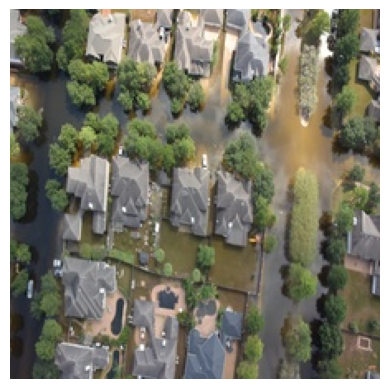

In [5]:
# This functions allows to pick a sample with labels equal to 1.
def pickNthSampleWithLabels(dataset, labelNames, n):
    labelIndices = [
        MULTILABEL_NAMES.index(labelName)
        for labelName in labelNames
    ]
    matchingIndices = torch.where(
        torch.all(
            dataset.labels[:, labelIndices] == 1,
            dim=1
        )
    )[0]
    if len(matchingIndices) == 0:
        raise ValueError(f"No samples found with labels: {labelNames}")
    if n >= len(matchingIndices):
        raise IndexError(f"Requested n={n}, but only {len(matchingIndices)} samples match {labelNames}")
    
    datasetIdx = int(matchingIndices[n].item())
    imageTensor, labelTensor = dataset[datasetIdx]
    imagePath = dataset.images[datasetIdx]
    image = Image.open(imagePath).convert("RGB")
    inputTensor = imageTensor.unsqueeze(0).to(DEVICE)
    trueValues = labelTensor.int().tolist()

    sample = {
    "datasetIdx": datasetIdx,
    "imagePath": imagePath,
    "image": image,
    "imageTensor": imageTensor,
    "inputTensor": inputTensor,
    "labelTensor": labelTensor,
    "trueValues": trueValues,
    "labelIndices": labelIndices,
    "labelNames": labelNames,
    }

    return sample

sample = pickNthSampleWithLabels(
    dataset=dataset,
    labelNames=LABELS_UNDER_TEST,
    n=NTH_SAMPLE
)
print(f"Dataset Index: {sample['datasetIdx']}")
print(f"Image Path: {sample['imagePath']}")
print(f"Ground Truth:")
print(
    {
        name: int(sample['labelTensor'][i].item())
        for i, name in enumerate(MULTILABEL_NAMES)
    }
)
plt.imshow(sample['image'])
plt.axis("off")
plt.show()

This giant cell is all for Grad-CAM. It runs Grad-CAM on both models, for both labels, and overlays the Grad-CAM map onto the original image.  
Grad-CAM originally makes sense on Conv-based models such as ResNet because they have 2D activation maps, but for Transformer-based models such as DeiT, I had to reshape the DeiT's patch tokens back into a 2D shape.  

Interpretation:  
Both models got the labels right, but ResNet model seems to have a more concentrated map, DeiT map is scattered all over the image, however, that doesn't mean that it's useless.  
Both models have very similar maps for roadFlooded and buildingFlooded labels, it seems like they have learnt a shared concept of "Flood" rather than separating the road and building flood concepts, that might be because in the dataset these two labels appear often together.  
ResNet is focusing on the big flooded area in the middle which has roads and buildings, DeiT on the other hand, is focusing more on details, like the narrow spaces in-between the houses and tree roots.  

On a side note, you can see that for both labels, ResNet is outputting higher probability, actually I got curious about this and ran a side-experiment, it turned out that ResNet is in general more over-confident and therefore, has higher ECE. As that experiment was irrelevant to my initial project proposal, I excluded it.

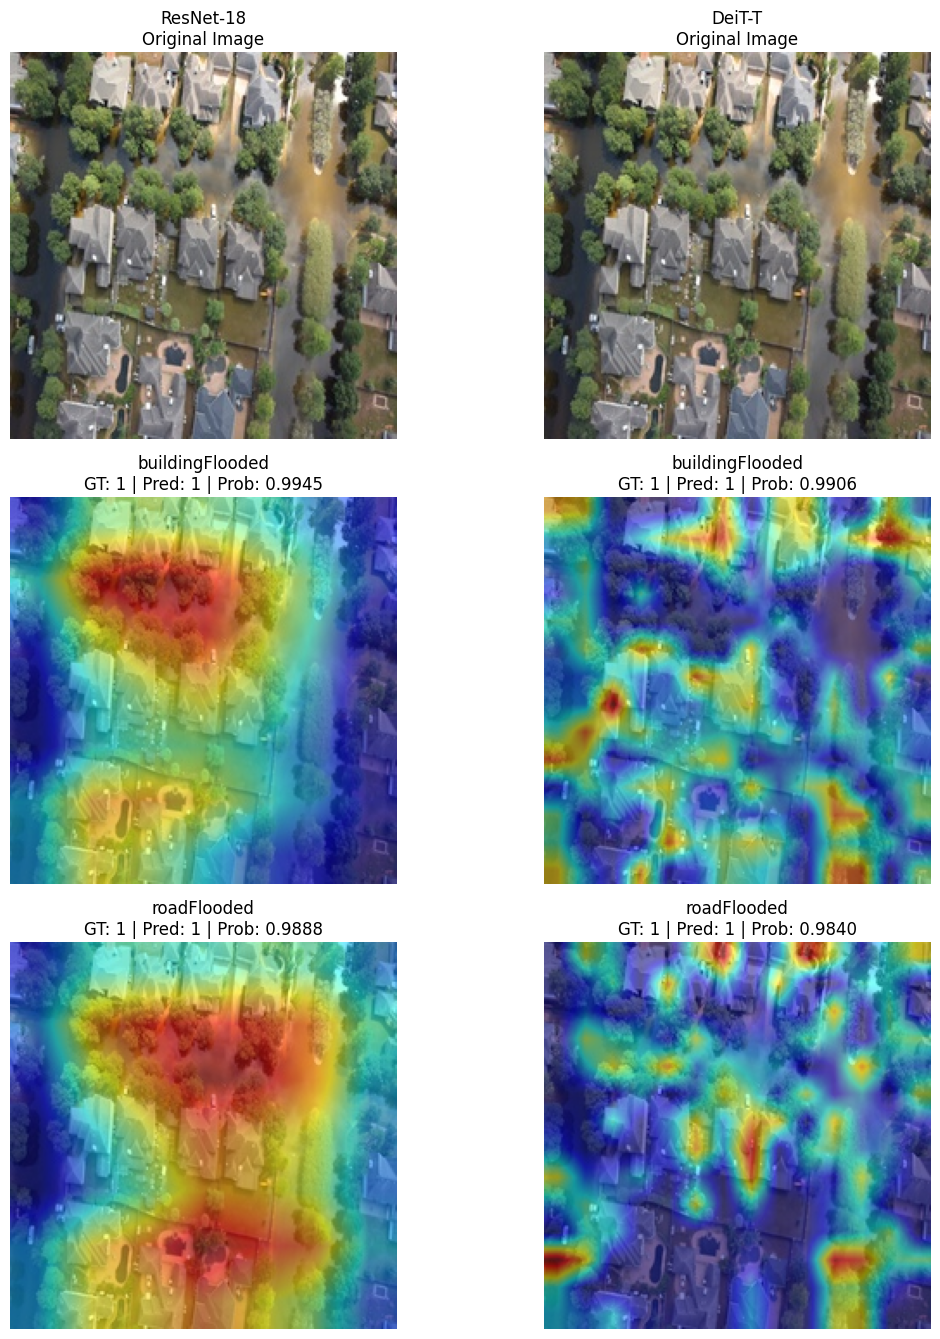

Saved Grad-CAM visualization to: Results/gradcamSample152.png
Correct Labels: ['buildingAny', 'buildingFlooded', 'roadAny', 'roadFlooded', 'tree', 'vehicle', 'pool', 'grass']
Predicted Labels (ResNet-18): ['buildingAny', 'buildingFlooded', 'roadAny', 'roadFlooded', 'tree', 'vehicle', 'pool', 'grass']
Predicted Labels (DeiT-T): ['buildingAny', 'buildingFlooded', 'roadAny', 'roadFlooded', 'tree', 'vehicle', 'pool', 'grass']


In [6]:
# Let's do Grad-CAM for the sample
def reshapeTransformForDeiT(tensor):
    result = tensor[:, 1:, :]
    result = result.reshape(tensor.size(0), 14, 14, tensor.size(2))
    result = result.permute(0, 3, 1, 2)
    return result


def buildGradCAM(modelName, model):
    if modelName == "ResNet-18":
        return GradCAM(
            model=model,
            target_layers=[model.layer4[-1]],
            reshape_transform=None
        )

    if modelName == "DeiT-T":
        return GradCAM(
            model=model,
            target_layers=[model.blocks[-1].norm1],
            reshape_transform=reshapeTransformForDeiT
        )


def gradCAMForSample(models, sample, labelsUnderTest):
    labelIndicesToPlot = [
        MULTILABEL_NAMES.index(labelName)
        for labelName in labelsUnderTest
    ]

    h, w = sample["inputTensor"].shape[-2:]
    rgbImg = np.array(sample["image"].resize((w, h)).convert("RGB")).astype(np.float32) / 255.0

    modelNames = list(models.keys())
    nCols = len(modelNames)
    nRows = 1 + len(labelIndicesToPlot)

    fig, axes = plt.subplots(
        nRows,
        nCols,
        figsize=(6 * nCols, 4.5 * nRows),
        squeeze=False
    )

    modelSummaries = {}

    for colIdx, modelName in enumerate(modelNames):
        model = models[modelName]
        model.eval()

        with torch.no_grad():
            logits = model(sample["inputTensor"])
            probs = torch.sigmoid(logits)[0].detach().cpu()

        predValues = (probs >= THRESHOLD).int().tolist()
        predictedLabels = [
            labelName
            for labelName, predValue in zip(MULTILABEL_NAMES, predValues)
            if predValue == 1
        ]
        if len(predictedLabels) == 0:
            predictedLabels = ["None"]

        modelSummaries[modelName] = predictedLabels

        axes[0, colIdx].imshow(sample["image"])
        axes[0, colIdx].set_title(f"{modelName}\nOriginal Image")
        axes[0, colIdx].axis("off")

        gradCam = buildGradCAM(modelName, model)

        for rowOffset, labelIdx in enumerate(labelIndicesToPlot, start=1):
            grayscaleCam = gradCam(
                input_tensor=sample["inputTensor"],
                targets=[ClassifierOutputTarget(labelIdx)]
            )[0]
            visualization = show_cam_on_image(
                rgbImg,
                grayscaleCam,
                use_rgb=True,
                image_weight=0.5
            )

            axes[rowOffset, colIdx].imshow(visualization)
            axes[rowOffset, colIdx].set_title(
                f"{MULTILABEL_NAMES[labelIdx]}\n"
                f"GT: {sample['trueValues'][labelIdx]} | "
                f"Pred: {predValues[labelIdx]} | "
                f"Prob: {probs[labelIdx]:.4f}"
            )
            axes[rowOffset, colIdx].axis("off")

    plt.tight_layout()

    savePath = RESULTS_DIR / f"gradcamSample{sample['datasetIdx']}.png"
    plt.savefig(savePath)
    plt.show()

    correctLabels = [
        labelName
        for labelName, trueValue in zip(MULTILABEL_NAMES, sample["trueValues"])
        if trueValue == 1
    ]
    if len(correctLabels) == 0:
        correctLabels = ["None"]

    print(f"Saved Grad-CAM visualization to: {savePath}")
    print(f"Correct Labels: {correctLabels}")
    for modelName, predictedLabels in modelSummaries.items():
        print(f"Predicted Labels ({modelName}): {predictedLabels}")


gradCAMForSample(
    models=models,
    sample=sample,
    labelsUnderTest=LABELS_UNDER_TEST
)

This whole cell is for LIME. As we learnt, LIME uses superpixels as features, in order to form those superpixels it needs a clustering (segmentation) function, Scikit-image (skimage) provides some of these algorithms, I found SLIC (Simple Linear Iterative Clustering) easy to understand, also its args were more understandable. Apparently it clusters based on both color similarity and spatial closeness, so distant pixels don't end up in the same segment, which makes the segments less sparse. Also I set the explainer to show only the positively-contributing superpixels, because the other option made the plot over-crowded.

Interpretation:  
Same as in Grad-CAM, we can see that the models are focusing on very similar areas for both labels, indicating that they're mainly learning the general concept of flood rather than separating roadFlood and buildingFlood.  
But LIME is clarifying another point as well; both models are focusing on buildings plus a flooded area which is not neccessarily adjacent to that building. It means that they're not actually looking at building edges to see if it's flooded, they look for relationship between building presence and flood presence.

100%|██████████| 1000/1000 [00:01<00:00, 703.39it/s]


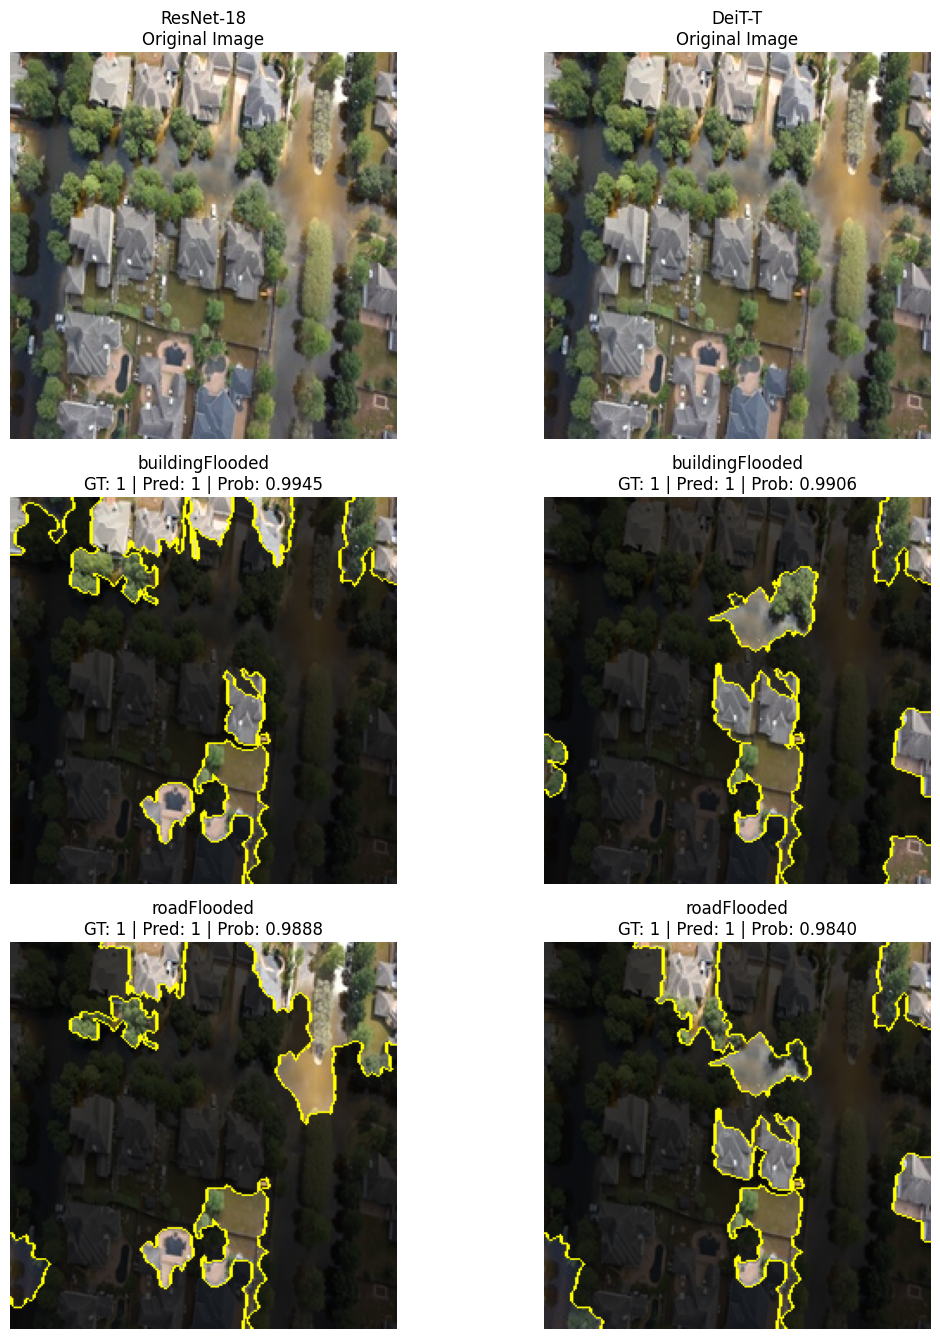

Saved LIME visualization to: Results/limeSample152.png
Correct Labels: ['buildingAny', 'buildingFlooded', 'roadAny', 'roadFlooded', 'tree', 'vehicle', 'pool', 'grass']
Predicted Labels (ResNet-18): ['buildingAny', 'buildingFlooded', 'roadAny', 'roadFlooded', 'tree', 'vehicle', 'pool', 'grass']
Predicted Labels (DeiT-T): ['buildingAny', 'buildingFlooded', 'roadAny', 'roadFlooded', 'tree', 'vehicle', 'pool', 'grass']


In [7]:
# Let's do LIME for the sample
def buildLimePredict(model):
    def limePredict(batchImages):
        batchImages = np.asarray(batchImages).astype(np.float32)
        if batchImages.max() > 1.0:
            batchImages = batchImages / 255.0

        batchTensor = torch.from_numpy(batchImages).permute(0, 3, 1, 2).to(DEVICE)
        batchTensor = (batchTensor - MEAN) / STD

        with torch.no_grad():
            logits = model(batchTensor)
            probs = torch.sigmoid(logits)

        return probs.detach().cpu().numpy()

    return limePredict


def segmentationFn(x):
    return slic(
        x,
        n_segments=100,
        compactness=10,
        sigma=1,
        start_label=0,
        channel_axis=-1
    )

    """
    return quickshift(
        x,
        kernel_size=3,
        max_dist=100,
        ratio=0.2,
        rng=SEED
    )
    """

def limeForSample(models, sample, labelsUnderTest):
    labelIndicesToPlot = [
        MULTILABEL_NAMES.index(labelName)
        for labelName in labelsUnderTest
    ]

    h, w = sample["inputTensor"].shape[-2:]
    limeImage = np.array(sample["image"].resize((w, h)).convert("RGB"))

    modelNames = list(models.keys())
    nCols = len(modelNames)
    nRows = 1 + len(labelIndicesToPlot)

    fig, axes = plt.subplots(
        nRows,
        nCols,
        figsize=(6 * nCols, 4.5 * nRows),
        squeeze=False
    )

    modelSummaries = {}

    for colIdx, modelName in enumerate(modelNames):
        model = models[modelName]
        model.eval()

        with torch.no_grad():
            logits = model(sample["inputTensor"])
            probs = torch.sigmoid(logits)[0].detach().cpu()

        predValues = (probs >= THRESHOLD).int().tolist()
        predictedLabels = [
            labelName
            for labelName, predValue in zip(MULTILABEL_NAMES, predValues)
            if predValue == 1
        ]
        if len(predictedLabels) == 0:
            predictedLabels = ["None"]

        modelSummaries[modelName] = predictedLabels

        axes[0, colIdx].imshow(sample["image"])
        axes[0, colIdx].set_title(f"{modelName}\nOriginal Image")
        axes[0, colIdx].axis("off")

        explainer = lime_image.LimeImageExplainer(random_state=SEED)
        explanation = explainer.explain_instance(
            limeImage,
            classifier_fn=buildLimePredict(model),
            labels=labelIndicesToPlot,
            top_labels=None,
            hide_color=0,
            num_samples=1000,
            batch_size=32,
            segmentation_fn=segmentationFn,
            random_seed=SEED
        )

        for rowOffset, labelIdx in enumerate(labelIndicesToPlot, start=1):
            temp, mask = explanation.get_image_and_mask(
                label=labelIdx,
                positive_only=True,
                num_features=10,
                hide_rest=False
            )

            limeViz = temp.copy().astype(np.float32)
            if limeViz.max() > 1.0:
                limeViz = limeViz / 255.0
            limeViz[mask == 0] *= 0.25
            limeViz = mark_boundaries(limeViz, mask)

            axes[rowOffset, colIdx].imshow(limeViz)
            axes[rowOffset, colIdx].set_title(
                f"{MULTILABEL_NAMES[labelIdx]}\n"
                f"GT: {sample['trueValues'][labelIdx]} | "
                f"Pred: {predValues[labelIdx]} | "
                f"Prob: {probs[labelIdx]:.4f}"
            )
            axes[rowOffset, colIdx].axis("off")

    plt.tight_layout()

    savePath = RESULTS_DIR / f"limeSample{sample['datasetIdx']}.png"
    plt.savefig(savePath)
    plt.show()

    correctLabels = [
        labelName
        for labelName, trueValue in zip(MULTILABEL_NAMES, sample["trueValues"])
        if trueValue == 1
    ]
    if len(correctLabels) == 0:
        correctLabels = ["None"]

    print(f"Saved LIME visualization to: {savePath}")
    print(f"Correct Labels: {correctLabels}")
    for modelName, predictedLabels in modelSummaries.items():
        print(f"Predicted Labels ({modelName}): {predictedLabels}")


limeForSample(
    models=models,
    sample=sample,
    labelsUnderTest=LABELS_UNDER_TEST
)


This last block is for SHAP. For this I'm using a blur masker, which creates many masked versions of the image, then based on the model's predictions on those perturbations, it estimates which region contributes positively, which one negatively. So in the output image, the red squares are positively contributing, the blue ones negatively, and the natural ones are less contributive.  

Interpretation:  
Again we can see the common flood concept being focused on for both labels in both models instead of separate roadFlooded and buildingFlooded, but here I think SHAP is working better on the DeiT model, in the ResNet map we can see that some parts of the main flooded street are marked as blue, which is not very logical. Maybe this is because of the patch-based nature of the transformers that allows SHAP squares to explain it better.

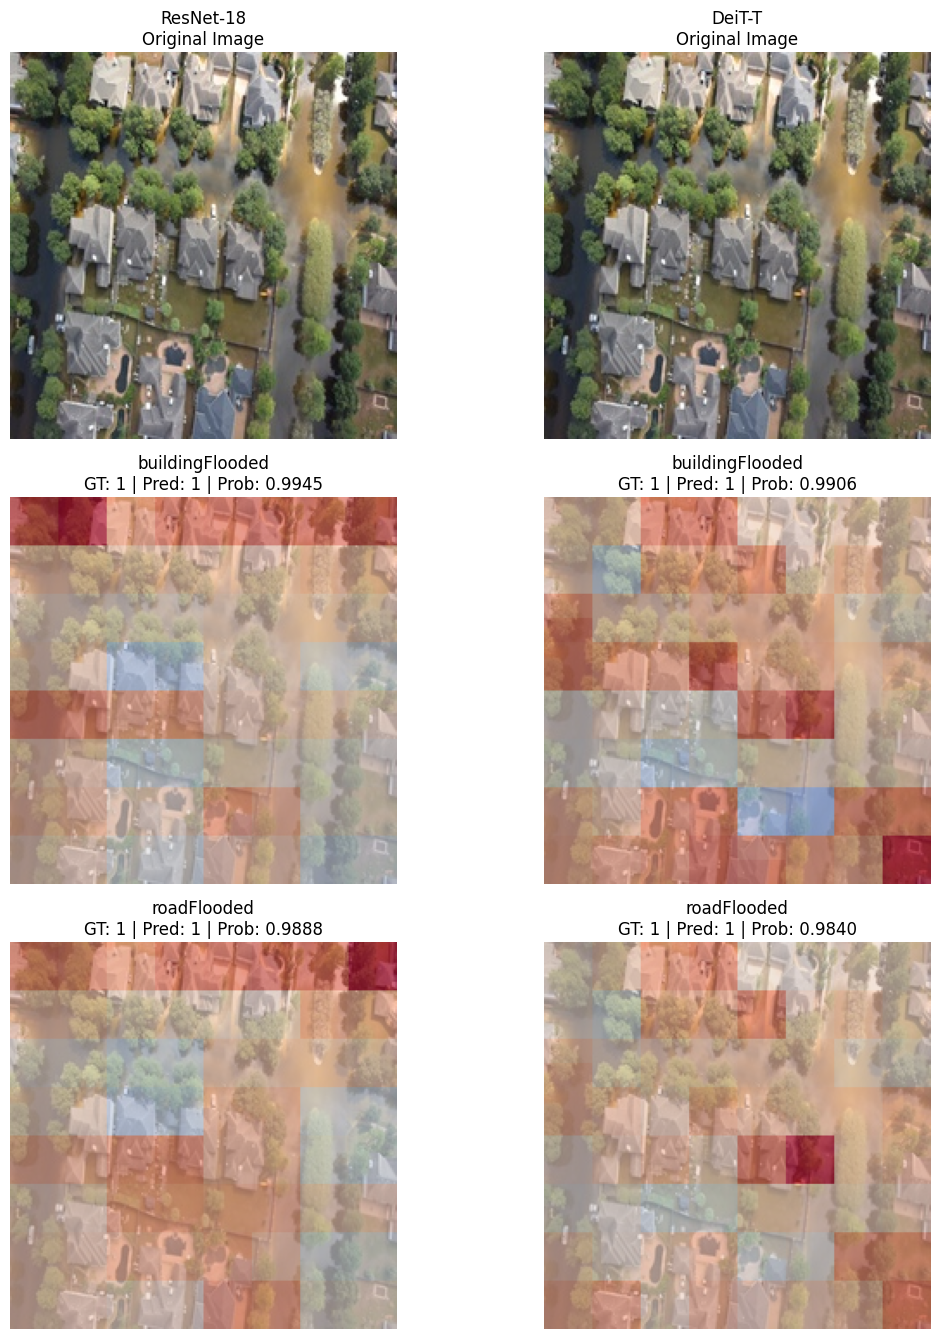

Saved image-masker SHAP visualization to: Results/shapImageMaskerSample152.png
Correct Labels: ['buildingAny', 'buildingFlooded', 'roadAny', 'roadFlooded', 'tree', 'vehicle', 'pool', 'grass']
Predicted Labels (ResNet-18): ['buildingAny', 'buildingFlooded', 'roadAny', 'roadFlooded', 'tree', 'vehicle', 'pool', 'grass']
Predicted Labels (DeiT-T): ['buildingAny', 'buildingFlooded', 'roadAny', 'roadFlooded', 'tree', 'vehicle', 'pool', 'grass']


In [ ]:
# Let's do SHAP for the sample
def buildShapPredictLogits(model):
    def shapPredictLogits(batchImages):
        batchImages = np.asarray(batchImages).astype(np.float32)
        if batchImages.max() > 1.0:
            batchImages = batchImages / 255.0

        batchTensor = torch.from_numpy(batchImages).permute(0, 3, 1, 2).to(DEVICE)
        batchTensor = (batchTensor - MEAN) / STD

        with torch.no_grad():
            logits = model(batchTensor)

        return logits.detach().cpu().numpy()

    return shapPredictLogits

def shapForSample(models, sample, labelsUnderTest):
    labelIndicesToPlot = [
        MULTILABEL_NAMES.index(labelName)
        for labelName in labelsUnderTest
    ]

    h, w = sample["inputTensor"].shape[-2:]
    shapImage = np.array(sample["image"].resize((w, h)).convert("RGB")).astype(np.float32) / 255.0

    modelNames = list(models.keys())
    nCols = len(modelNames)
    nRows = 1 + len(labelIndicesToPlot)

    fig, axes = plt.subplots(
        nRows,
        nCols,
        figsize=(6 * nCols, 4.5 * nRows),
        squeeze=False
    )

    modelSummaries = {}
    shapOutputShapes = {}

    for colIdx, modelName in enumerate(modelNames):
        model = models[modelName]
        model.eval()

        with torch.no_grad():
            logits = model(sample["inputTensor"])[0].detach().cpu()
            probs = torch.sigmoid(logits)

        predValues = (probs >= THRESHOLD).int().tolist()
        predictedLabels = [
            labelName
            for labelName, predValue in zip(MULTILABEL_NAMES, predValues)
            if predValue == 1
        ]
        if len(predictedLabels) == 0:
            predictedLabels = ["None"]

        modelSummaries[modelName] = predictedLabels

        axes[0, colIdx].imshow(sample["image"])
        axes[0, colIdx].set_title(f"{modelName}\nOriginal Image")
        axes[0, colIdx].axis("off")

        masker = shap.maskers.Image("blur(64,64)", shapImage.shape)
        maskerExplainer = shap.Explainer(
            buildShapPredictLogits(model),
            masker,
            output_names=MULTILABEL_NAMES,
            seed=SEED
        )

        maskerShapValues = maskerExplainer(
            shapImage[None, ...],
            max_evals=500,
            batch_size=32,
            outputs=labelIndicesToPlot
        )
        shapOutputShapes[modelName] = np.asarray(maskerShapValues.values).shape

        for rowOffset, labelIdx in enumerate(labelIndicesToPlot, start=1):
            outputPosition = rowOffset - 1
            values = np.asarray(maskerShapValues.values)
            labelValues = values[0, :, :, :, outputPosition]
            shapMap = labelValues.sum(axis=-1)
            vmax = np.percentile(np.abs(shapMap), 99)
            if vmax == 0:
                vmax = 1e-8

            axes[rowOffset, colIdx].imshow(shapImage)
            axes[rowOffset, colIdx].imshow(
                shapMap,
                cmap="coolwarm",
                alpha=0.60,
                vmin=-vmax,
                vmax=vmax
            )
            axes[rowOffset, colIdx].set_title(
                f"{MULTILABEL_NAMES[labelIdx]}\n"
                f"GT: {sample['trueValues'][labelIdx]} | "
                f"Pred: {predValues[labelIdx]} | "
                f"Prob: {probs[labelIdx]:.4f}"
            )
            axes[rowOffset, colIdx].axis("off")

    plt.tight_layout()

    savePath = RESULTS_DIR / f"shapImageMaskerSample{sample['datasetIdx']}.png"
    plt.savefig(savePath)
    plt.show()

    correctLabels = [
        labelName
        for labelName, trueValue in zip(MULTILABEL_NAMES, sample["trueValues"])
        if trueValue == 1
    ]
    if len(correctLabels) == 0:
        correctLabels = ["None"]

    print(f"Saved image-masker SHAP visualization to: {savePath}")
    print(f"Correct Labels: {correctLabels}")
    for modelName, predictedLabels in modelSummaries.items():
        print(f"Predicted Labels ({modelName}): {predictedLabels}")
        

shapForSample(
    models=models,
    sample=sample,
    labelsUnderTest=LABELS_UNDER_TEST
)
